# Notebook 6: Claims Triage and Resource Allocation

Gulf Crest has 2,035 open claims and a limited number of adjusters who can process a fixed number of them
each day. Working through the pile in whatever order it happens to sit in is a choice, just a bad one: a
$1.2 million commercial claim and a $600 windshield claim do not deserve the same place in line.

This notebook builds a simple scoring system to rank claims by how urgently they should be worked, and then
measures what that ranking actually buys Gulf Crest compared to the alternative, in extra dollars, days, and
fairness. It deliberately does not reach for a linear programming solver. A transparent, explainable scoring
formula is often the more practical choice in a claims department, where adjusters need to understand and
trust why a claim landed where it did in their queue.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 20)

TODAY = pd.Timestamp("2026-08-17")

DATA_DIR = "../04_Datasets/"
claims = pd.read_csv(DATA_DIR + "02_claims.csv")

print("Data loaded.")

Data loaded.


## 1. The Open Claims Queue

Only open claims need triage; closed ones are already resolved. `days_open` measures how long each claim
has been sitting since it was reported, which matters both for customer service and because several states
require insurers to act on claims within a set number of days.

In [2]:
claims["date_reported"] = pd.to_datetime(claims["date_reported"])
open_claims = claims[claims["claim_status"] == "Open"].copy()
open_claims["days_open"] = (TODAY - open_claims["date_reported"]).dt.days

print(f"Open claims: {len(open_claims)} of {len(claims)} total")
print()
print(open_claims[["reported_severity", "days_open"]].describe())

Open claims: 2035 of 2883 total

       reported_severity    days_open
count       2.035000e+03  2035.000000
mean        8.094962e+04    50.164619
std         1.622022e+05   167.812779
min         3.262800e+02     0.000000
25%         1.644068e+04    20.000000
50%         3.413097e+04    24.000000
75%         7.726173e+04    27.000000
max         3.258045e+06  1786.000000


## 2. Building a Priority Score

Three factors go into the score, each rescaled to a common 0-to-1 range with min-max scaling so that
dollar amounts (in the tens of thousands) and days (in the tens) can be combined without one simply
dominating the other by virtue of its raw size:

- **Severity** (50% weight): larger claims tie up more reserve capital and carry more financial risk if
  mishandled, so they are weighted most heavily.
- **Age** (30% weight): a claim that has already waited longer gets a boost, both for customer service and
  to avoid claims aging indefinitely at the bottom of the queue.
- **Catastrophe flag** (20% weight): claims from Hurricane Marisol get an added boost, reflecting the
  reputational and regulatory attention a major declared catastrophe draws that routine claims do not.

These weights are a judgment call made explicit here, not derived from the data. A real claims department
would set them through management policy, and revisit them as priorities shift.

In [3]:
def minmax_scale(series):
    return (series - series.min()) / (series.max() - series.min())

open_claims["severity_score"] = minmax_scale(open_claims["reported_severity"])
open_claims["age_score"] = minmax_scale(open_claims["days_open"])
open_claims["catastrophe_score"] = (open_claims["is_catastrophe_flag"] == "Y").astype(float)

SEVERITY_WEIGHT, AGE_WEIGHT, CATASTROPHE_WEIGHT = 0.5, 0.3, 0.2

open_claims["priority_score"] = (
    SEVERITY_WEIGHT * open_claims["severity_score"]
    + AGE_WEIGHT * open_claims["age_score"]
    + CATASTROPHE_WEIGHT * open_claims["catastrophe_score"]
)

open_claims.sort_values("priority_score", ascending=False)[
    ["claim_id", "reported_severity", "days_open", "is_catastrophe_flag", "priority_score"]
].head(10)

,claim_id,reported_severity,days_open,is_catastrophe_flag,priority_score
1936,CLM-001937,3258045.00,19,Y,0.703191
1946,CLM-001947,1939485.50,26,Y,0.501993
1851,CLM-001852,1480950.82,23,Y,0.431112
2533,CLM-002534,1482495.00,20,Y,0.430845
2436,CLM-002437,1455332.13,20,Y,0.426676
2385,CLM-002386,1286184.51,30,Y,0.402395
1154,CLM-001155,1213659.28,27,Y,0.390760
1062,CLM-001063,1092420.00,12,Y,0.369632
1161,CLM-001162,1022808.78,26,Y,0.361300
1293,CLM-001294,1000827.16,28,Y,0.358262


## 3. Simulating the Queue Under a Capacity Constraint

Gulf Crest's adjuster team is assumed able to close 100 claims per day, a stated capacity assumption rather
than a figure pulled from the data. Three ways of ordering the same queue are compared:

- **Priority score**: highest score processed first
- **FIFO** (first in, first out): oldest claim processed first, the default most claims departments fall
  into without a deliberate scoring system
- **Random**: claims processed in no particular order, included as a baseline for how much of the
  difference below is actually coming from the ordering choice, rather than from the mere fact of imposing
  some order.

In [4]:
CAPACITY_PER_DAY = 100

def simulate_queue(df, order_by=None, ascending=False, random_seed=None):
    queue = df.copy()
    if random_seed is not None:
        queue = queue.sample(frac=1, random_state=random_seed).reset_index(drop=True)
    else:
        queue = queue.sort_values(order_by, ascending=ascending).reset_index(drop=True)
    queue["day_processed"] = np.arange(len(queue)) // CAPACITY_PER_DAY
    queue["days_to_close"] = queue["day_processed"] + 1
    return queue

priority_queue = simulate_queue(open_claims, order_by="priority_score", ascending=False)
fifo_queue = simulate_queue(open_claims, order_by="days_open", ascending=False)
random_queue = simulate_queue(open_claims, random_seed=42)

days_to_clear = priority_queue["days_to_close"].max()
print(f"Days needed to clear the full backlog at {CAPACITY_PER_DAY} claims/day: {days_to_clear}")

Days needed to clear the full backlog at 100 claims/day: 21


## 4. Comparing the Three Orderings

Two measures matter here. **Dollar-weighted average days to close** answers "how long, on average, does a
dollar of claim exposure sit unresolved," weighting each claim's wait by its size, since a large claim
sitting unresolved matters more than a small one. **Average days for the largest 10% of claims** answers a
narrower, more direct question: are the claims that matter most financially actually getting handled
quickly?

In [5]:
def summarize(queue, label):
    dollar_weighted_days = np.average(queue["days_to_close"], weights=queue["reported_severity"])
    top_decile_cutoff = open_claims["reported_severity"].quantile(0.90)
    bottom_decile_cutoff = open_claims["reported_severity"].quantile(0.10)
    large_claims = queue[queue["reported_severity"] >= top_decile_cutoff]
    small_claims = queue[queue["reported_severity"] <= bottom_decile_cutoff]
    return {
        "Ordering": label,
        "Dollar-Weighted Avg Days": round(dollar_weighted_days, 2),
        "Avg Days, Largest 10% of Claims": round(large_claims["days_to_close"].mean(), 2),
        "Avg Days, Smallest 10% of Claims": round(small_claims["days_to_close"].mean(), 2),
    }

comparison = pd.DataFrame([
    summarize(priority_queue, "Priority Score"),
    summarize(fifo_queue, "FIFO (Oldest First)"),
    summarize(random_queue, "Random"),
])
comparison

,Ordering,Dollar-Weighted Avg Days,"Avg Days, Largest 10% of Claims","Avg Days, Smallest 10% of Claims"
0,Priority Score,4.35,1.60,18.62
1,FIFO (Oldest First),11.22,11.30,8.14
2,Random,10.34,10.55,10.49


Priority scoring cuts the dollar-weighted wait roughly in half compared to FIFO or random ordering, and
gets the largest claims resolved in under two days on average instead of eleven. That is the efficiency gain
the scoring system was built for.

It comes at a cost that deserves equal attention: the smallest claims wait noticeably longer under priority
scoring than under FIFO. A minor claim that would have been handled in about a week under a simple
first-in-first-out queue can now wait more than two and a half weeks, since it never accumulates enough
severity or age score to compete with larger, newer claims. This is not a bug in the scoring formula. It is
the direct, mechanical consequence of what the formula was told to optimize for, and it is worth stating
plainly rather than only reporting the good numbers.

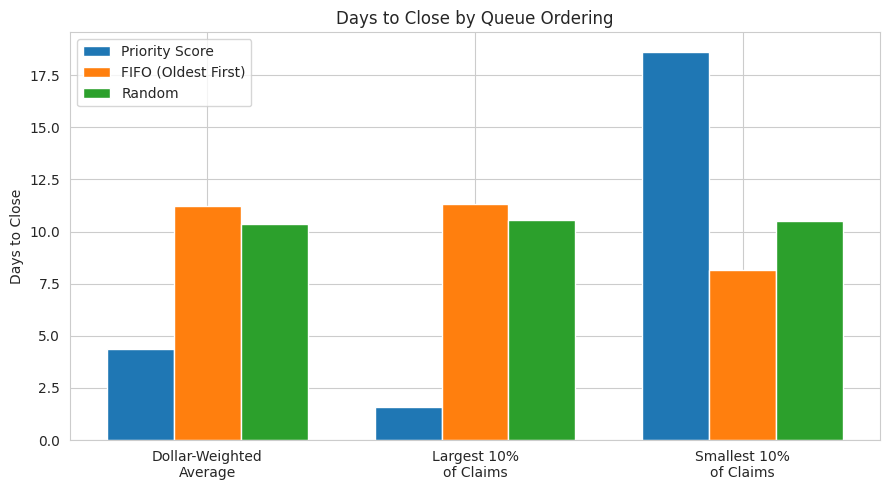

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
metrics = ["Dollar-Weighted Avg Days", "Avg Days, Largest 10% of Claims", "Avg Days, Smallest 10% of Claims"]
x = np.arange(len(metrics))
width = 0.25

for i, ordering in enumerate(comparison["Ordering"]):
    values = comparison.loc[comparison["Ordering"] == ordering, metrics].values.flatten()
    ax.bar(x + (i - 1) * width, values, width, label=ordering)

ax.set_xticks(x)
ax.set_xticklabels(["Dollar-Weighted\nAverage", "Largest 10%\nof Claims", "Smallest 10%\nof Claims"])
ax.set_ylabel("Days to Close")
ax.set_title("Days to Close by Queue Ordering")
ax.legend()
plt.tight_layout()
plt.savefig("outputs_triage_comparison.png", dpi=120)
plt.show()

## 5. A Simple Fix: Reserving Capacity for the Oldest Claims

Rather than treating this as an either-or choice, a small change addresses most of the fairness concern
without giving up much of the efficiency gain: reserve a fixed share of each day's capacity for the oldest
remaining claims regardless of their score, and let priority scoring govern the rest. No solver is needed,
only a rule: fill 20% of each day's capacity oldest-first, then fill the remaining 80% by priority score.

In [7]:
RESERVED_CAPACITY_FRACTION = 0.20
reserved_slots_per_day = int(CAPACITY_PER_DAY * RESERVED_CAPACITY_FRACTION)
priority_slots_per_day = CAPACITY_PER_DAY - reserved_slots_per_day

remaining = open_claims.copy()
remaining["sim_day"] = np.nan
day = 0
while remaining["sim_day"].isna().any():
    unprocessed = remaining[remaining["sim_day"].isna()]

    oldest_first = unprocessed.sort_values("days_open", ascending=False).head(reserved_slots_per_day).index
    remaining.loc[oldest_first, "sim_day"] = day

    unprocessed = remaining[remaining["sim_day"].isna()]
    by_priority = unprocessed.sort_values("priority_score", ascending=False).head(priority_slots_per_day).index
    remaining.loc[by_priority, "sim_day"] = day

    day += 1

remaining["days_to_close"] = remaining["sim_day"] + 1
hybrid_summary = summarize(remaining, "Hybrid (20% Reserved for Oldest)")
pd.DataFrame([
    summarize(priority_queue, "Priority Score Only"),
    summarize(fifo_queue, "FIFO Only"),
    hybrid_summary,
])

,Ordering,Dollar-Weighted Avg Days,"Avg Days, Largest 10% of Claims","Avg Days, Smallest 10% of Claims"
0,Priority Score Only,4.35,1.60,18.62
1,FIFO Only,11.22,11.30,8.14
2,Hybrid (20% Reserved for Oldest),4.77,1.82,13.58


Reserving just one-fifth of daily capacity for the oldest remaining claims cuts the smallest claims'
average wait meaningfully, while the largest claims and the dollar-weighted average both barely move. This
is the kind of adjustment a claims department can actually explain to a regulator or a customer: nothing
waits forever, no matter how small, and the claims that matter most financially still move quickly.

## Summary

1. A limited daily capacity means claims must be worked in some order, and choosing that order deliberately
   produces measurably better outcomes than defaulting to first-in-first-out or leaving it unmanaged.
2. A transparent, weighted scoring formula, built from severity, age, and catastrophe status, cut the
   dollar-weighted average wait roughly in half and got the largest claims resolved nearly six times faster
   than FIFO, without requiring an optimization solver.
3. That efficiency gain has a real cost: small claims wait substantially longer under pure priority scoring.
   A scoring system optimizes exactly what it is told to, nothing more, and the trade-offs it makes should
   be surfaced, not hidden behind a single headline number.
4. Reserving a small, fixed share of daily capacity for the oldest claims regardless of score recovered most
   of the fairness lost, at almost no cost to the efficiency gained, using nothing more complex than a rule.

**Next:** Open `07_Scenario_Analysis.ipynb` to test how these results hold up under different assumptions.